# Fraud Detection Model Comparison
## Isolation Forest vs Autoencoder

This notebook compares the two fraud-detection experiments using the saved result JSON files.

**Canonical model notebooks**
- `Isolation_Forest_Model_Test.ipynb`
- `Autoencoder_Model_Test.ipynb`

The comparison is designed to use the same PaySim experiment dimensions and report:
- Precision
- Recall
- F1-score
- PR-AUC
- ROC-AUC
- TP / TN / FP / FN
- False-positive rate
- False-negative rate
- Training time
- Inference latency / throughput
- Operating threshold
- Model characteristics

> Threshold values are model-specific and must not be compared numerically across models because the underlying score scales differ.


In [1]:
# ============================================================
# BLOCK 1 — IMPORT LIBRARIES
# ============================================================

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 90)
print("FRAUD DETECTION MODEL COMPARISON")
print("Isolation Forest vs Deep Autoencoder")
print("=" * 90)

print("NumPy :", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", __import__("matplotlib").__version__)
print()
print("Environment ready.")


FRAUD DETECTION MODEL COMPARISON
Isolation Forest vs Deep Autoencoder
NumPy : 2.2.6
Pandas: 2.3.3
Matplotlib: 3.10.9

Environment ready.


In [2]:
# ============================================================
# BLOCK 2 — CONFIGURATION
# ============================================================

RESULT_DIR = Path(r".\results")

# Canonical result files produced by the model notebooks
ISOLATION_FOREST_RESULT = RESULT_DIR / "isolation_forest_final_results.json"
AUTOENCODER_RESULT = RESULT_DIR / "autoencoder_final_results.json"

print("=" * 90)
print("BLOCK 2 — RESULT FILE CONFIGURATION")
print("=" * 90)

print("Isolation Forest:", ISOLATION_FOREST_RESULT)
print("Autoencoder     :", AUTOENCODER_RESULT)


BLOCK 2 — RESULT FILE CONFIGURATION
Isolation Forest: results\isolation_forest_final_results.json
Autoencoder     : results\autoencoder_final_results.json


In [3]:
# ============================================================
# BLOCK 3 — CHECK RESULT FILES
# ============================================================

print("=" * 90)
print("BLOCK 3 — FILE CHECK")
print("=" * 90)

for label, path in [
    ("Isolation Forest", ISOLATION_FOREST_RESULT),
    ("Autoencoder", AUTOENCODER_RESULT),
]:
    print(f"{label:20s}: {'FOUND' if path.exists() else 'NOT FOUND'}")
    print(f"Path: {path.resolve()}")
    print()

if not ISOLATION_FOREST_RESULT.exists():
    raise FileNotFoundError(
        f"Missing Isolation Forest results: {ISOLATION_FOREST_RESULT}"
    )

if not AUTOENCODER_RESULT.exists():
    raise FileNotFoundError(
        f"Missing Autoencoder results: {AUTOENCODER_RESULT}"
    )

print("Both result files are available.")


BLOCK 3 — FILE CHECK
Isolation Forest    : FOUND
Path: D:\Real-Time-Financial-Fraud-Detection-Pipeline-\results\isolation_forest_final_results.json

Autoencoder         : FOUND
Path: D:\Real-Time-Financial-Fraud-Detection-Pipeline-\results\autoencoder_final_results.json

Both result files are available.


In [4]:
# ============================================================
# BLOCK 4 — LOAD RESULTS
# ============================================================

with open(ISOLATION_FOREST_RESULT, "r", encoding="utf-8") as f:
    if_results = json.load(f)

with open(AUTOENCODER_RESULT, "r", encoding="utf-8") as f:
    ae_results = json.load(f)

print("=" * 90)
print("BLOCK 4 — RESULTS LOADED")
print("=" * 90)

print("\nIsolation Forest keys:")
print(sorted(if_results.keys()))

print("\nAutoencoder keys:")
print(sorted(ae_results.keys()))


BLOCK 4 — RESULTS LOADED

Isolation Forest keys:
['dataset', 'f1', 'false_negative_rate', 'false_negatives', 'false_positive_rate', 'false_positives', 'inference_latency_ms_per_transaction', 'max_features', 'max_samples', 'model', 'n_estimators', 'n_features', 'normal_train_rows', 'pr_auc', 'precision', 'random_state', 'recall', 'roc_auc', 'rows_loaded', 'scores_file', 'search_results_file', 'test_inference_time_seconds', 'test_rows', 'threshold', 'throughput_transactions_per_second', 'train_rows', 'training_time_seconds', 'true_negatives', 'true_positives', 'validation_rows']

Autoencoder keys:
['best_epoch', 'best_training_loss', 'best_validation_loss', 'dataset', 'epochs_completed', 'epochs_requested', 'f1_score', 'false_negative_rate', 'false_negatives', 'false_positive_rate', 'false_positives', 'model', 'model_architecture', 'number_of_features', 'pr_auc', 'precision', 'recall', 'roc_auc', 'rows_loaded', 'test_rows', 'threshold', 'training_rows', 'training_time_seconds', 'true_neg

In [5]:
# ============================================================
# BLOCK 5 — HELPER FUNCTION
# ============================================================

def get_value(data, *keys, default=np.nan):
    """Return the first available key from a result dictionary."""
    for key in keys:
        if key in data and data[key] is not None:
            return data[key]
    return default

print("Helper function created.")


Helper function created.


In [6]:
# ============================================================
# BLOCK 6 — EXPERIMENT CONSISTENCY
# ============================================================

checks = [
    ("Rows loaded",
     get_value(if_results, "rows_loaded"),
     get_value(ae_results, "rows_loaded")),

    ("Number of features",
     get_value(if_results, "n_features", "number_of_features"),
     get_value(ae_results, "n_features", "number_of_features")),

    ("Training rows",
     get_value(if_results, "train_rows", "training_rows"),
     get_value(ae_results, "train_rows", "training_rows")),

    ("Validation rows",
     get_value(if_results, "validation_rows"),
     get_value(ae_results, "validation_rows")),

    ("Test rows",
     get_value(if_results, "test_rows"),
     get_value(ae_results, "test_rows")),

    ("Normal training rows",
     get_value(if_results, "normal_train_rows"),
     get_value(ae_results, "normal_train_rows")),
]

consistency_df = pd.DataFrame(
    [
        {
            "Experiment Dimension": name,
            "Isolation Forest": left,
            "Autoencoder": right,
            "Match": left == right,
        }
        for name, left, right in checks
    ]
)

print("=" * 90)
print("BLOCK 6 — EXPERIMENT CONSISTENCY CHECK")
print("=" * 90)
display(consistency_df)

if consistency_df["Match"].all():
    print("\nAll recorded experiment dimensions match.")
else:
    print("\nWARNING: One or more experiment dimensions do not match.")
    print("Interpret metric differences only after checking the two notebooks.")


BLOCK 6 — EXPERIMENT CONSISTENCY CHECK


,Experiment Dimension,Isolation Forest,Autoencoder,Match
0,Rows loaded,500000,500000.0,True
1,Number of features,19,19.0,True
2,Training rows,300000,299860.0,False
3,Validation rows,100000,100000.0,True
4,Test rows,100000,100000.0,True
5,Normal training rows,299860,NaN,False



Interpret metric differences only after checking the two notebooks.


In [7]:
# ============================================================
# BLOCK 7 — MAIN PERFORMANCE TABLE
# ============================================================

metric_rows = [
    ("Precision", "precision", "precision"),
    ("Recall", "recall", "recall"),
    ("F1-score", "f1", "f1_score"),
    ("PR-AUC", "pr_auc", "pr_auc"),
    ("ROC-AUC", "roc_auc", "roc_auc"),
    ("True Positives", "true_positives", "true_positives"),
    ("True Negatives", "true_negatives", "true_negatives"),
    ("False Positives", "false_positives", "false_positives"),
    ("False Negatives", "false_negatives", "false_negatives"),
    ("False Positive Rate", "false_positive_rate", "false_positive_rate"),
    ("False Negative Rate", "false_negative_rate", "false_negative_rate"),
    ("Training Time (sec)", "training_time_seconds", "training_time_seconds"),
    ("Inference Time (sec)", "test_inference_time_seconds", "test_inference_time_seconds"),
    ("Latency (ms/transaction)",
     "inference_latency_ms_per_transaction",
     "inference_latency_ms_per_transaction"),
    ("Throughput (transactions/sec)",
     "throughput_transactions_per_second",
     "throughput_transactions_per_second"),
    ("Operating Threshold", "threshold", "threshold"),
]

performance_table = pd.DataFrame([
    {
        "Metric": label,
        "Isolation Forest": get_value(if_results, if_key),
        "Autoencoder": get_value(ae_results, ae_key),
    }
    for label, if_key, ae_key in metric_rows
])

print("=" * 90)
print("BLOCK 7 — MAIN PERFORMANCE TABLE")
print("=" * 90)
display(performance_table)


BLOCK 7 — MAIN PERFORMANCE TABLE


,Metric,Isolation Forest,Autoencoder
0,Precision,0.148515,0.112245
1,Recall,0.319149,0.234043
2,F1-score,0.202703,0.151724
3,PR-AUC,0.194957,0.156055
4,ROC-AUC,0.856945,0.906317
5,True Positives,15.000000,11.000000
6,True Negatives,99867.000000,99866.000000
7,False Positives,86.000000,87.000000
8,False Negatives,32.000000,36.000000
9,False Positive Rate,0.000860,0.000870


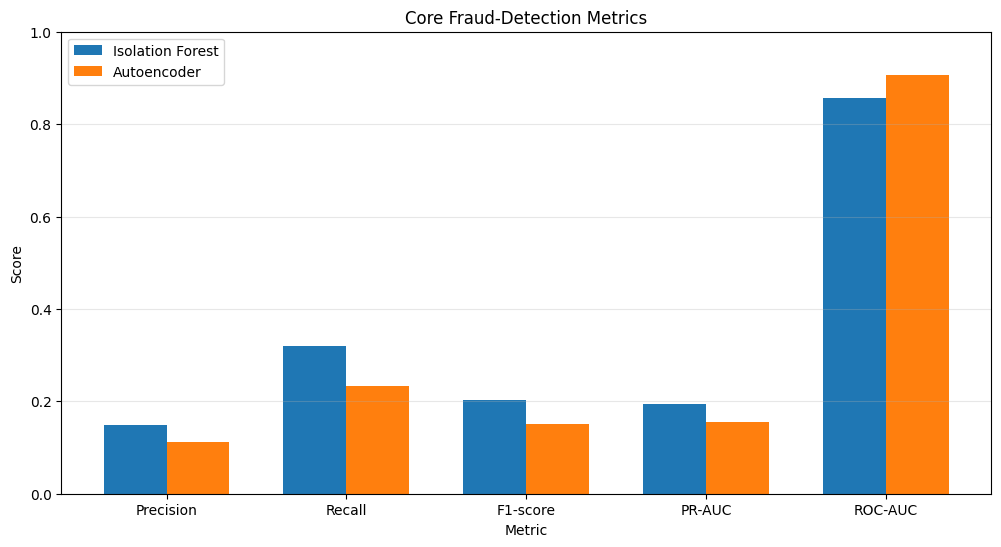

In [8]:
# ============================================================
# BLOCK 8 — CORE METRICS BAR CHART
# ============================================================

core_names = ["Precision", "Recall", "F1-score", "PR-AUC", "ROC-AUC"]
core = performance_table[
    performance_table["Metric"].isin(core_names)
].copy()

x = np.arange(len(core))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width / 2, core["Isolation Forest"], width, label="Isolation Forest")
plt.bar(x + width / 2, core["Autoencoder"], width, label="Autoencoder")

plt.xticks(x, core["Metric"])
plt.ylim(0, 1)
plt.ylabel("Score")
plt.xlabel("Metric")
plt.title("Core Fraud-Detection Metrics")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()


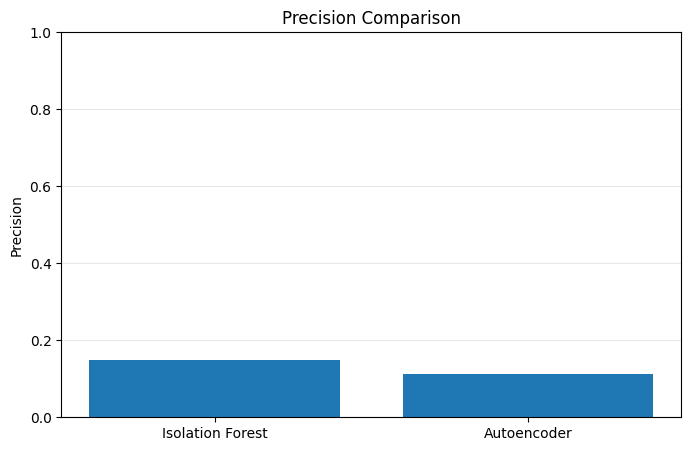

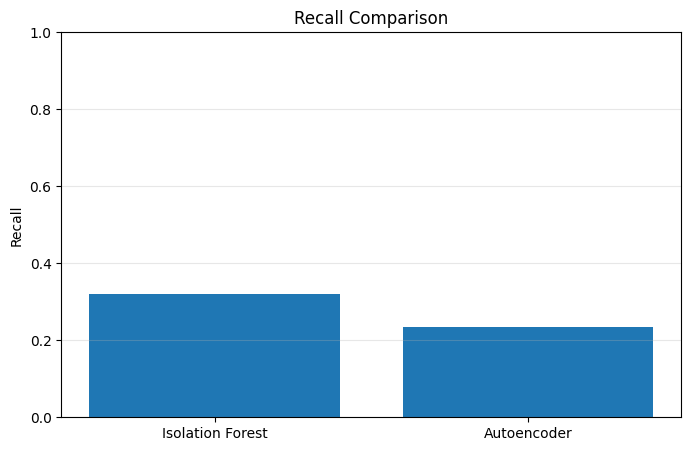

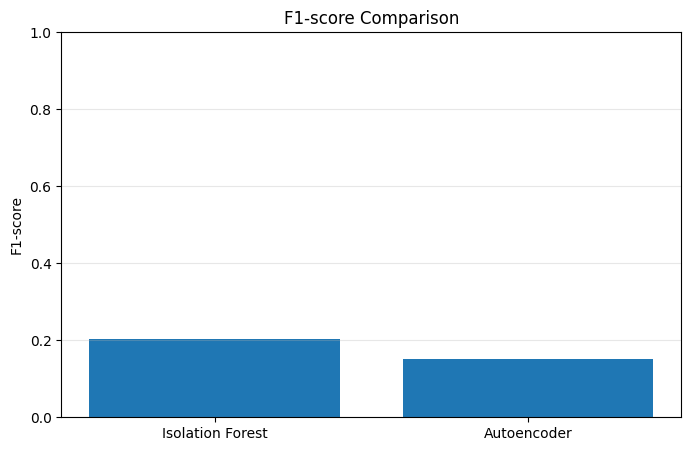

In [9]:
# ============================================================
# BLOCK 9 — PRECISION, RECALL AND F1 INDIVIDUAL DIAGRAMS
# ============================================================

for metric in ["Precision", "Recall", "F1-score"]:

    row = performance_table[
        performance_table["Metric"] == metric
    ].iloc[0]

    values = [
        row["Isolation Forest"],
        row["Autoencoder"]
    ]

    plt.figure(figsize=(8, 5))
    plt.bar(
        ["Isolation Forest", "Autoencoder"],
        values
    )

    plt.ylim(0, 1)
    plt.ylabel(metric)
    plt.title(f"{metric} Comparison")
    plt.grid(axis="y", alpha=0.3)
    plt.show()


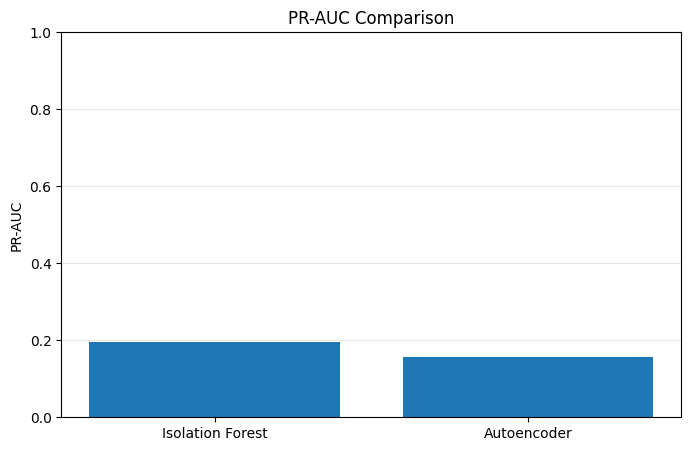

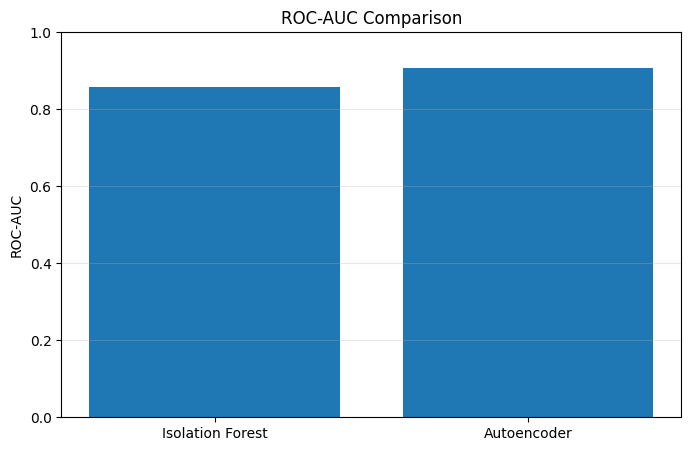

In [10]:
# ============================================================
# BLOCK 10 — PR-AUC AND ROC-AUC DIAGRAMS
# ============================================================

for metric in ["PR-AUC", "ROC-AUC"]:

    row = performance_table[
        performance_table["Metric"] == metric
    ].iloc[0]

    plt.figure(figsize=(8, 5))
    plt.bar(
        ["Isolation Forest", "Autoencoder"],
        [row["Isolation Forest"], row["Autoencoder"]]
    )

    plt.ylim(0, 1)
    plt.ylabel(metric)
    plt.title(f"{metric} Comparison")
    plt.grid(axis="y", alpha=0.3)
    plt.show()


In [11]:
# ============================================================
# BLOCK 11 — CONFUSION MATRIX DATA
# ============================================================

if_cm = np.array([
    [
        if_results["true_negatives"],
        if_results["false_positives"]
    ],
    [
        if_results["false_negatives"],
        if_results["true_positives"]
    ]
])

ae_cm = np.array([
    [
        ae_results["true_negatives"],
        ae_results["false_positives"]
    ],
    [
        ae_results["false_negatives"],
        ae_results["true_positives"]
    ]
])

print("=" * 90)
print("BLOCK 11 — CONFUSION MATRIX VALUES")
print("=" * 90)

print("\nIsolation Forest")
display(pd.DataFrame(
    if_cm,
    index=["Actual Legitimate", "Actual Fraud"],
    columns=["Predicted Legitimate", "Predicted Fraud"]
))

print("\nAutoencoder")
display(pd.DataFrame(
    ae_cm,
    index=["Actual Legitimate", "Actual Fraud"],
    columns=["Predicted Legitimate", "Predicted Fraud"]
))


BLOCK 11 — CONFUSION MATRIX VALUES

Isolation Forest


,Predicted Legitimate,Predicted Fraud
Actual Legitimate,99867,86
Actual Fraud,32,15



Autoencoder


,Predicted Legitimate,Predicted Fraud
Actual Legitimate,99866,87
Actual Fraud,36,11


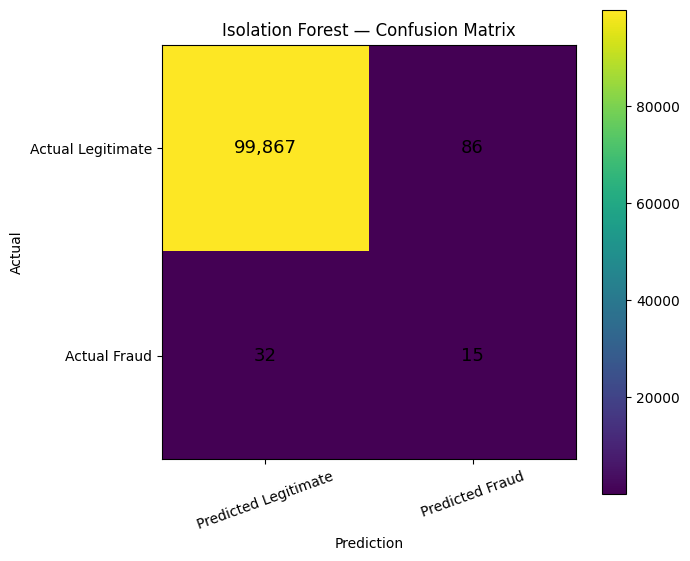

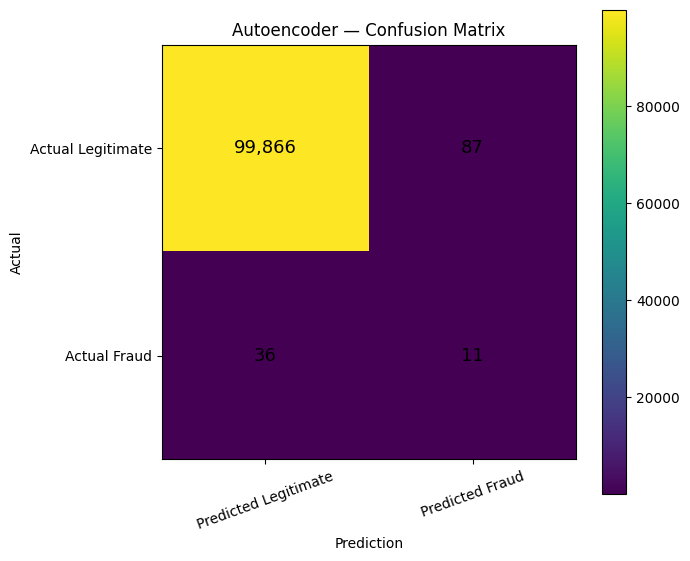

In [12]:
# ============================================================
# BLOCK 12 — CONFUSION MATRIX HEATMAPS
# ============================================================

def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(7, 6))
    plt.imshow(cm)
    plt.xticks([0, 1], ["Predicted Legitimate", "Predicted Fraud"], rotation=20)
    plt.yticks([0, 1], ["Actual Legitimate", "Actual Fraud"])

    for i in range(2):
        for j in range(2):
            plt.text(
                j,
                i,
                f"{cm[i, j]:,}",
                ha="center",
                va="center",
                fontsize=13
            )

    plt.xlabel("Prediction")
    plt.ylabel("Actual")
    plt.title(title)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(
    if_cm,
    "Isolation Forest — Confusion Matrix"
)

plot_confusion_matrix(
    ae_cm,
    "Autoencoder — Confusion Matrix"
)


BLOCK 13 — ERROR ANALYSIS


,Model,False Positives,False Negatives,False Positive Rate,False Negative Rate
0,Isolation Forest,86,32,0.00086,0.680851
1,Autoencoder,87,36,0.00087,0.765957


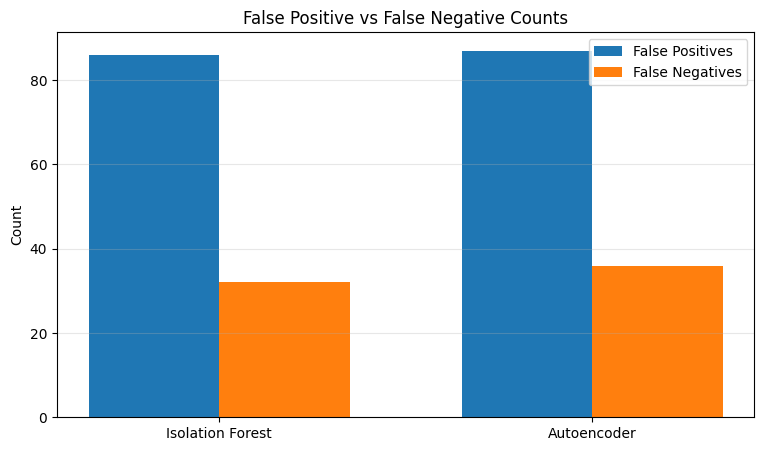

In [13]:
# ============================================================
# BLOCK 13 — FALSE POSITIVE / FALSE NEGATIVE ANALYSIS
# ============================================================

error_df = pd.DataFrame({
    "Model": ["Isolation Forest", "Autoencoder"],
    "False Positives": [
        if_results["false_positives"],
        ae_results["false_positives"]
    ],
    "False Negatives": [
        if_results["false_negatives"],
        ae_results["false_negatives"]
    ],
    "False Positive Rate": [
        get_value(if_results, "false_positive_rate"),
        get_value(ae_results, "false_positive_rate")
    ],
    "False Negative Rate": [
        get_value(if_results, "false_negative_rate"),
        get_value(ae_results, "false_negative_rate")
    ],
})

print("=" * 90)
print("BLOCK 13 — ERROR ANALYSIS")
print("=" * 90)
display(error_df)

plt.figure(figsize=(9, 5))
x = np.arange(2)
width = 0.35

plt.bar(
    x - width / 2,
    error_df["False Positives"],
    width,
    label="False Positives"
)

plt.bar(
    x + width / 2,
    error_df["False Negatives"],
    width,
    label="False Negatives"
)

plt.xticks(x, error_df["Model"])
plt.ylabel("Count")
plt.title("False Positive vs False Negative Counts")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()


In [14]:
# ============================================================
# BLOCK 14 — TRAINING AND INFERENCE COST
# ============================================================

runtime = pd.DataFrame({
    "Model": ["Isolation Forest", "Autoencoder"],
    "Training Time (sec)": [
        if_results["training_time_seconds"],
        ae_results["training_time_seconds"]
    ],
    "Inference Time (sec)": [
        get_value(if_results, "test_inference_time_seconds"),
        get_value(ae_results, "test_inference_time_seconds")
    ],
    "Latency (ms/transaction)": [
        get_value(if_results, "inference_latency_ms_per_transaction"),
        get_value(ae_results, "inference_latency_ms_per_transaction")
    ],
    "Throughput (transactions/sec)": [
        get_value(if_results, "throughput_transactions_per_second"),
        get_value(ae_results, "throughput_transactions_per_second")
    ],
})

print("=" * 90)
print("BLOCK 14 — COMPUTATIONAL PERFORMANCE")
print("=" * 90)
display(runtime)


BLOCK 14 — COMPUTATIONAL PERFORMANCE


,Model,Training Time (sec),Inference Time (sec),Latency (ms/transaction),Throughput (transactions/sec)
0,Isolation Forest,16.766859,6.251271,0.062513,15996.746902
1,Autoencoder,191.700643,NaN,NaN,NaN


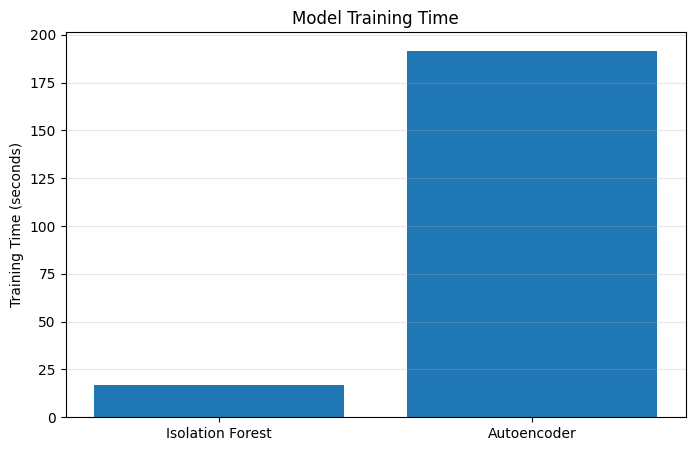

In [15]:
# ============================================================
# BLOCK 15 — TRAINING TIME DIAGRAM
# ============================================================

plt.figure(figsize=(8, 5))
plt.bar(
    runtime["Model"],
    runtime["Training Time (sec)"]
)

plt.ylabel("Training Time (seconds)")
plt.title("Model Training Time")
plt.grid(axis="y", alpha=0.3)
plt.show()


In [16]:
# ============================================================
# BLOCK 16 — LATENCY AND THROUGHPUT DIAGRAMS
# ============================================================

latency_available = runtime["Latency (ms/transaction)"].notna().all()
throughput_available = runtime["Throughput (transactions/sec)"].notna().all()

if latency_available:
    plt.figure(figsize=(8, 5))
    plt.bar(
        runtime["Model"],
        runtime["Latency (ms/transaction)"]
    )
    plt.ylabel("Milliseconds / transaction")
    plt.title("Inference Latency")
    plt.grid(axis="y", alpha=0.3)
    plt.show()
else:
    print("Latency diagram skipped: one or both models did not save latency.")

if throughput_available:
    plt.figure(figsize=(8, 5))
    plt.bar(
        runtime["Model"],
        runtime["Throughput (transactions/sec)"]
    )
    plt.ylabel("Transactions / second")
    plt.title("Inference Throughput")
    plt.grid(axis="y", alpha=0.3)
    plt.show()
else:
    print("Throughput diagram skipped: one or both models did not save throughput.")


Latency diagram skipped: one or both models did not save latency.
Throughput diagram skipped: one or both models did not save throughput.


## Model Architecture Comparison

| Dimension | Isolation Forest | Autoencoder |
|---|---|---|
| Model family | Tree ensemble | Deep neural network |
| Learning idea | Isolation of observations | Reconstruction of inputs |
| Anomaly score | Isolation score | Reconstruction error |
| Main hyperparameters | Trees, sample size, feature sampling | Layers, latent dimension, learning rate, epochs |
| Threshold | Score-specific | Reconstruction-error-specific |
| Scaling requirement | Generally less sensitive | Important for stable neural-network training |
| Interpretability | Path/isolation based | Reconstruction-error based |
| Typical engineering focus | Fast anomaly detection | Non-linear representation learning |


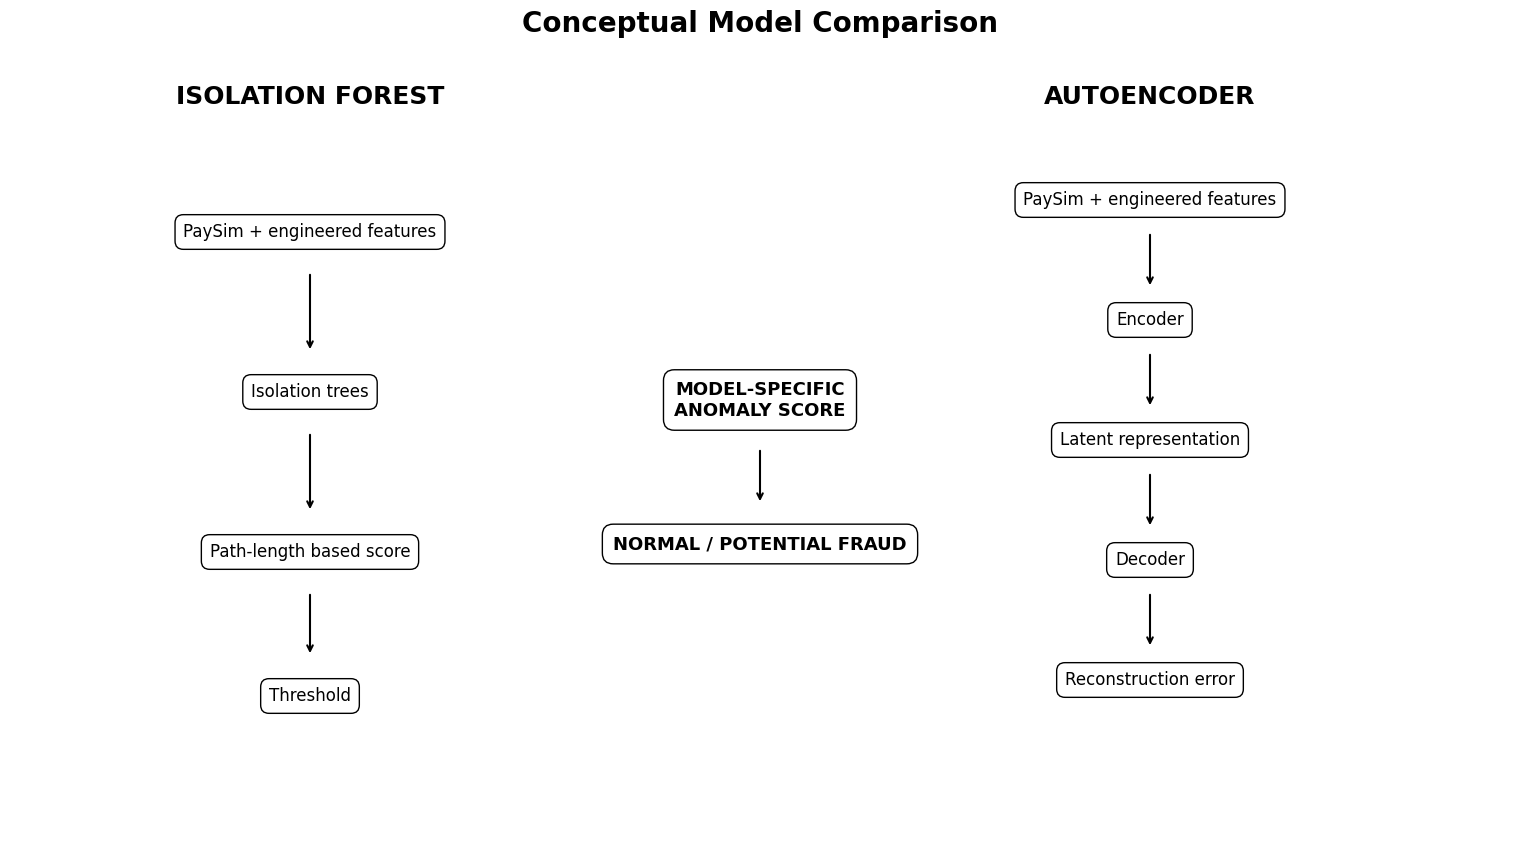

In [17]:
# ============================================================
# BLOCK 17 — MODEL FLOW DIAGRAM
# ============================================================

fig = plt.figure(figsize=(15, 8))
ax = fig.add_axes([0, 0, 1, 1])
ax.axis("off")

# Isolation Forest side
ax.text(
    0.20, 0.92,
    "ISOLATION FOREST",
    fontsize=18,
    fontweight="bold",
    ha="center"
)

if_steps = [
    ("PaySim + engineered features", 0.76),
    ("Isolation trees", 0.56),
    ("Path-length based score", 0.36),
    ("Threshold", 0.18),
]

for label, y in if_steps:
    ax.text(
        0.20, y, label,
        fontsize=12,
        ha="center",
        va="center",
        bbox=dict(boxstyle="round,pad=0.5", fill=False)
    )

for y1, y2 in [(0.71, 0.61), (0.51, 0.41), (0.31, 0.23)]:
    ax.annotate(
        "",
        xy=(0.20, y2),
        xytext=(0.20, y1),
        arrowprops=dict(arrowstyle="->", linewidth=1.5)
    )

# Autoencoder side
ax.text(
    0.76, 0.92,
    "AUTOENCODER",
    fontsize=18,
    fontweight="bold",
    ha="center"
)

ae_steps = [
    ("PaySim + engineered features", 0.80),
    ("Encoder", 0.65),
    ("Latent representation", 0.50),
    ("Decoder", 0.35),
    ("Reconstruction error", 0.20),
]

for label, y in ae_steps:
    ax.text(
        0.76, y, label,
        fontsize=12,
        ha="center",
        va="center",
        bbox=dict(boxstyle="round,pad=0.5", fill=False)
    )

for y1, y2 in [(0.76, 0.69), (0.61, 0.54), (0.46, 0.39), (0.31, 0.24)]:
    ax.annotate(
        "",
        xy=(0.76, y2),
        xytext=(0.76, y1),
        arrowprops=dict(arrowstyle="->", linewidth=1.5)
    )

# Shared decision
ax.text(
    0.50, 0.55,
    "MODEL-SPECIFIC\nANOMALY SCORE",
    fontsize=13,
    fontweight="bold",
    ha="center",
    va="center",
    bbox=dict(boxstyle="round,pad=0.6", fill=False)
)

ax.text(
    0.50, 0.37,
    "NORMAL / POTENTIAL FRAUD",
    fontsize=13,
    fontweight="bold",
    ha="center",
    va="center",
    bbox=dict(boxstyle="round,pad=0.6", fill=False)
)

ax.annotate(
    "",
    xy=(0.50, 0.42),
    xytext=(0.50, 0.49),
    arrowprops=dict(arrowstyle="->", linewidth=1.5)
)

ax.set_title(
    "Conceptual Model Comparison",
    fontsize=20,
    fontweight="bold"
)

plt.show()


In [18]:
# ============================================================
# BLOCK 18 — THRESHOLD EXPLANATION
# ============================================================

threshold_table = pd.DataFrame({
    "Model": ["Isolation Forest", "Autoencoder"],
    "Threshold": [
        get_value(if_results, "threshold"),
        get_value(ae_results, "threshold")
    ],
    "Meaning": [
        "Model-specific cutoff on the Isolation Forest anomaly score",
        "Model-specific cutoff on reconstruction error"
    ]
})

print("=" * 90)
print("BLOCK 18 — THRESHOLD INTERPRETATION")
print("=" * 90)
display(threshold_table)

print("""
Thresholds are not directly comparable numerically.

For Isolation Forest:
    anomaly score -> threshold -> normal / anomaly

For Autoencoder:
    reconstruction error -> threshold -> normal / anomaly

The threshold is an operating point selected for the specific model
and validation-score distribution.
""")


BLOCK 18 — THRESHOLD INTERPRETATION


,Model,Threshold,Meaning
0,Isolation Forest,0.107197,Model-specific cutoff on the Isolation Forest ...
1,Autoencoder,1.747206,Model-specific cutoff on reconstruction error



Thresholds are not directly comparable numerically.

For Isolation Forest:
    anomaly score -> threshold -> normal / anomaly

For Autoencoder:
    reconstruction error -> threshold -> normal / anomaly

The threshold is an operating point selected for the specific model
and validation-score distribution.



In [19]:
# ============================================================
# BLOCK 19 — TEST-SET FRAUD DETECTION SUMMARY
# ============================================================

test_fraud = pd.DataFrame({
    "Model": ["Isolation Forest", "Autoencoder"],
    "Actual Fraud": [
        if_results["true_positives"] + if_results["false_negatives"],
        ae_results["true_positives"] + ae_results["false_negatives"]
    ],
    "Fraud Detected (TP)": [
        if_results["true_positives"],
        ae_results["true_positives"]
    ],
    "Fraud Missed (FN)": [
        if_results["false_negatives"],
        ae_results["false_negatives"]
    ],
    "Recall": [
        if_results["recall"],
        ae_results["recall"]
    ]
})

print("=" * 90)
print("BLOCK 19 — FRAUD DETECTION SUMMARY")
print("=" * 90)
display(test_fraud)


BLOCK 19 — FRAUD DETECTION SUMMARY


,Model,Actual Fraud,Fraud Detected (TP),Fraud Missed (FN),Recall
0,Isolation Forest,47,15,32,0.319149
1,Autoencoder,47,11,36,0.234043


In [20]:
# ============================================================
# BLOCK 20 — FINAL RESEARCH TABLE
# ============================================================

final_research_table = pd.DataFrame({
    "Dimension": [
        "Model family",
        "Learning mechanism",
        "Anomaly score",
        "Precision",
        "Recall",
        "F1-score",
        "PR-AUC",
        "ROC-AUC",
        "False Positives",
        "False Negatives",
        "Training Time (sec)",
        "Inference Latency (ms/transaction)",
        "Throughput (transactions/sec)"
    ],

    "Isolation Forest": [
        "Tree ensemble",
        "Isolation-based",
        "Isolation score",
        if_results["precision"],
        if_results["recall"],
        if_results["f1"],
        if_results["pr_auc"],
        if_results["roc_auc"],
        if_results["false_positives"],
        if_results["false_negatives"],
        if_results["training_time_seconds"],
        get_value(if_results, "inference_latency_ms_per_transaction"),
        get_value(if_results, "throughput_transactions_per_second")
    ],

    "Autoencoder": [
        "Deep neural network",
        "Reconstruction-based",
        "Reconstruction error",
        ae_results["precision"],
        ae_results["recall"],
        ae_results["f1_score"],
        ae_results["pr_auc"],
        ae_results["roc_auc"],
        ae_results["false_positives"],
        ae_results["false_negatives"],
        ae_results["training_time_seconds"],
        get_value(ae_results, "inference_latency_ms_per_transaction"),
        get_value(ae_results, "throughput_transactions_per_second")
    ]
})

print("=" * 90)
print("BLOCK 20 — FINAL RESEARCH COMPARISON TABLE")
print("=" * 90)
display(final_research_table)


BLOCK 20 — FINAL RESEARCH COMPARISON TABLE


,Dimension,Isolation Forest,Autoencoder
0,Model family,Tree ensemble,Deep neural network
1,Learning mechanism,Isolation-based,Reconstruction-based
2,Anomaly score,Isolation score,Reconstruction error
3,Precision,0.148515,0.112245
4,Recall,0.319149,0.234043
5,F1-score,0.202703,0.151724
6,PR-AUC,0.194957,0.156055
7,ROC-AUC,0.856945,0.906317
8,False Positives,86,87
9,False Negatives,32,36


In [21]:
# ============================================================
# BLOCK 21 — SAVE COMPARISON TABLES
# ============================================================

RESULT_DIR.mkdir(parents=True, exist_ok=True)

performance_csv = RESULT_DIR / "model_comparison_performance.csv"
research_csv = RESULT_DIR / "model_comparison_research.csv"

performance_table.to_csv(
    performance_csv,
    index=False
)

final_research_table.to_csv(
    research_csv,
    index=False
)

print("=" * 90)
print("BLOCK 21 — FILES SAVED")
print("=" * 90)

print("Saved:", performance_csv.resolve())
print("Saved:", research_csv.resolve())
print()
print("Model comparison completed.")


BLOCK 21 — FILES SAVED
Saved: D:\Real-Time-Financial-Fraud-Detection-Pipeline-\results\model_comparison_performance.csv
Saved: D:\Real-Time-Financial-Fraud-Detection-Pipeline-\results\model_comparison_research.csv

Model comparison completed.


## Interpretation Framework

This notebook intentionally does **not** select a model by a hard-coded rule.

Use the recorded evidence together:

**Fraud-detection quality**
- Recall / false negatives
- Precision / false positives
- F1-score
- PR-AUC

**Operational performance**
- Training time
- Inference latency
- Throughput

**Engineering considerations**
- Model complexity
- Deployment requirements
- Reproducibility
- Threshold stability
- Monitoring requirements

The final model-selection decision should be documented from the measured results of the same test protocol.
